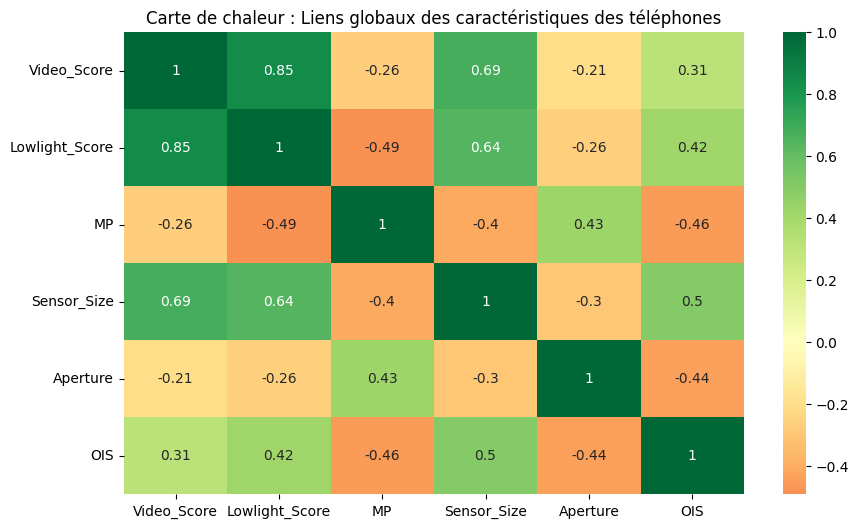

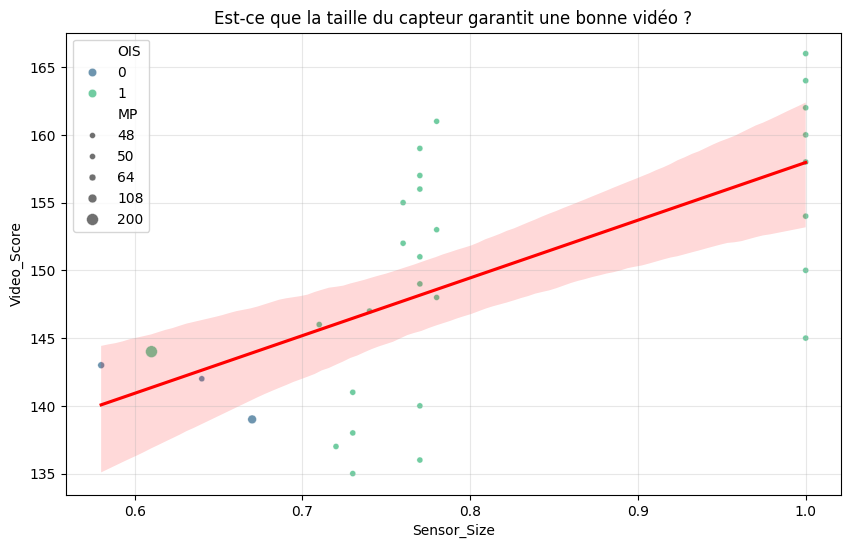

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Charger tes données
df = pd.read_csv('smartphone_data_clean.csv')

# 2. Créer la Heatmap pour voir les liens globaux
plt.figure(figsize=(10, 6))
corr = df.drop('Model', axis=1).corr(method='spearman') # On enlève le nom pour le calcul
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0)
plt.title('Carte de chaleur : Liens globaux des caractéristiques des téléphones')
plt.show()

# 3. Taille du Capteur vs Score Vidéo
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sensor_Size', y='Video_Score', size='MP', hue='OIS', palette='viridis', alpha=0.7)
sns.regplot(data=df, x='Sensor_Size', y='Video_Score', scatter=False, color='red') # La ligne de tendance

plt.title('Est-ce que la taille du capteur garantit une bonne vidéo ?')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.0 kB 217.9 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 326.8 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 359.6 kB/s eta 0:00:00
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB 991.0 kB/s eta 0:00:09
    --------------------------------------- 0.2/8.1 MB 2.4 MB/s eta 0:00:04
   - -------------------------------------- 0.3/8.1 MB 2.5 MB/s eta 0:00:04
   -- ------------------------------------- 0.4/8.1 MB 3.1 MB/s eta 0:00:03
   --- ------------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
#Modele predicitif : regression multiple 

from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Préparation des variables (X = les causes, y = le résultat)
X = df[['Sensor_Size', 'MP', 'Aperture', 'OIS']]
y = df['Video_Score']

# 2. Création et entraînement du modèle
model = LinearRegression()
model.fit(X, y)

# 3. Extraction des coefficients
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Impact_sur_le_Score'])
print(coefficients)

# 4. Score de précision du modèle (R²)
print(f"Précision du modèle (R²) : {model.score(X, y):.2f}")

             Impact_sur_le_Score
Sensor_Size            41.662684
MP                      0.000093
Aperture                4.331267
OIS                     1.845390
Précision du modèle (R²) : 0.39
